# Analisis Image Captioning

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if (ROOT / 'src').exists():
    pass
elif ROOT.name == 'notebooks' and ROOT.parent.name == 'src':
    ROOT = ROOT.parents[1]
elif (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
else:
    raise RuntimeError('Could not resolve repository root.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from src.captioning.config import load_captioning_config
from src.captioning.data import load_caption_dataset
from src.captioning.evaluation import sentence_bleu


In [2]:
report_dir = ROOT / 'reports/captioning'
model_dir = ROOT / 'models/captioning'

summary_df = pd.read_csv(report_dir / 'experiment_summary.csv') if (report_dir / 'experiment_summary.csv').exists() else pd.DataFrame()
ranked_df = pd.read_csv(report_dir / 'ranked_runs.csv') if (report_dir / 'ranked_runs.csv').exists() else pd.DataFrame()
effects_df = pd.read_csv(report_dir / 'hyperparameter_effects.csv') if (report_dir / 'hyperparameter_effects.csv').exists() else pd.DataFrame()
history_df = pd.read_csv(report_dir / 'training_history_long.csv') if (report_dir / 'training_history_long.csv').exists() else pd.DataFrame()
max_length_df = pd.read_csv(report_dir / 'max_caption_length_comparison.csv') if (report_dir / 'max_caption_length_comparison.csv').exists() else pd.DataFrame()

scratch_payloads = []
for path in sorted(report_dir.glob('keras_vs_scratch_*.json')):
    payload = json.loads(path.read_text(encoding='utf-8'))
    scratch_payloads.append(payload)
scratch_summary_df = pd.DataFrame([payload['summary'] for payload in scratch_payloads]) if scratch_payloads else pd.DataFrame()

best_rnn_df = pd.read_csv(report_dir / 'best_rnn.csv') if (report_dir / 'best_rnn.csv').exists() else pd.DataFrame()
best_lstm_df = pd.read_csv(report_dir / 'best_lstm.csv') if (report_dir / 'best_lstm.csv').exists() else pd.DataFrame()

summary_df.head()

,run_id,decoder_type,layer_count,hidden_size,split,bleu4,meteor,runtime_seconds,model_dir
0,lstm_preinject_layers1_hidden128,lstm,1,128,test,0.055652,0.367537,595.051066,models/captioning/lstm_preinject_layers1_hidde...
1,lstm_preinject_layers1_hidden512,lstm,1,512,test,0.054492,0.377153,708.131153,models/captioning/lstm_preinject_layers1_hidde...
2,lstm_preinject_layers2_hidden128,lstm,2,128,test,0.067935,0.365004,522.967955,models/captioning/lstm_preinject_layers2_hidde...
3,lstm_preinject_layers2_hidden512,lstm,2,512,test,0.065348,0.368593,640.209934,models/captioning/lstm_preinject_layers2_hidde...
4,lstm_preinject_layers3_hidden128,lstm,3,128,test,0.062892,0.369171,528.810869,models/captioning/lstm_preinject_layers3_hidde...


## A. Variasi Jumlah Layer dan Hidden State

Bagian ini meninjau seluruh konfigurasi yang dilatih pada decoder Keras. Tabel dan grafik di bawah dipakai untuk melihat pola umum performa RNN dan LSTM terhadap perubahan jumlah layer recurrent dan ukuran hidden state.

In [3]:
display_cols = ['rank', 'run_id', 'decoder_type', 'layer_count', 'hidden_size', 'bleu4', 'meteor', 'runtime_seconds']
if not ranked_df.empty:
    display(ranked_df[display_cols])
else:
    print('ranked_runs.csv belum tersedia')

,rank,run_id,decoder_type,layer_count,hidden_size,bleu4,meteor,runtime_seconds
0,1,lstm_preinject_layers2_hidden128,lstm,2,128,0.067935,0.365004,522.967955
1,2,lstm_preinject_layers2_hidden512,lstm,2,512,0.065348,0.368593,640.209934
2,3,lstm_preinject_layers3_hidden512,lstm,3,512,0.063457,0.368995,598.880270
3,4,lstm_preinject_layers3_hidden128,lstm,3,128,0.062892,0.369171,528.810869
4,5,rnn_preinject_layers2_hidden128,rnn,2,128,0.060451,0.359176,538.919824
5,6,rnn_preinject_layers1_hidden128,rnn,1,128,0.057340,0.347912,467.809240
6,7,lstm_preinject_layers1_hidden128,lstm,1,128,0.055652,0.367537,595.051066
7,8,lstm_preinject_layers1_hidden512,lstm,1,512,0.054492,0.377153,708.131153
8,9,rnn_preinject_layers3_hidden512,rnn,3,512,0.047277,0.328944,602.280096
9,10,rnn_preinject_layers1_hidden512,rnn,1,512,0.047255,0.338667,494.458106


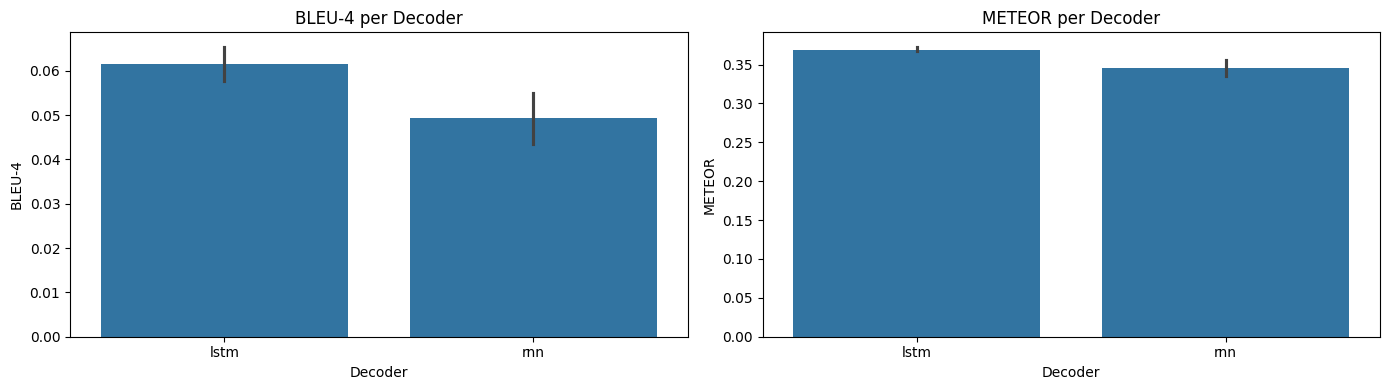

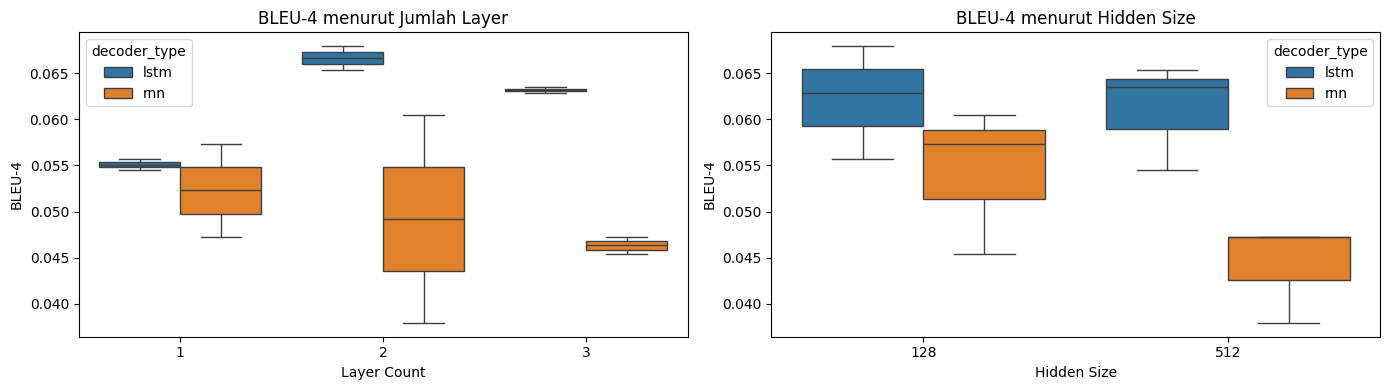

In [4]:
if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=summary_df, x='decoder_type', y='bleu4', ax=axes[0])
    axes[0].set_title('BLEU-4 per Decoder')
    axes[0].set_xlabel('Decoder')
    axes[0].set_ylabel('BLEU-4')

    sns.barplot(data=summary_df, x='decoder_type', y='meteor', ax=axes[1])
    axes[1].set_title('METEOR per Decoder')
    axes[1].set_xlabel('Decoder')
    axes[1].set_ylabel('METEOR')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.boxplot(data=summary_df, x='layer_count', y='bleu4', hue='decoder_type', ax=axes[0])
    axes[0].set_title('BLEU-4 menurut Jumlah Layer')
    axes[0].set_xlabel('Layer Count')
    axes[0].set_ylabel('BLEU-4')

    sns.boxplot(data=summary_df, x='hidden_size', y='bleu4', hue='decoder_type', ax=axes[1])
    axes[1].set_title('BLEU-4 menurut Hidden Size')
    axes[1].set_xlabel('Hidden Size')
    axes[1].set_ylabel('BLEU-4')
    plt.tight_layout()
    plt.show()
else:
    print('experiment_summary.csv belum tersedia')

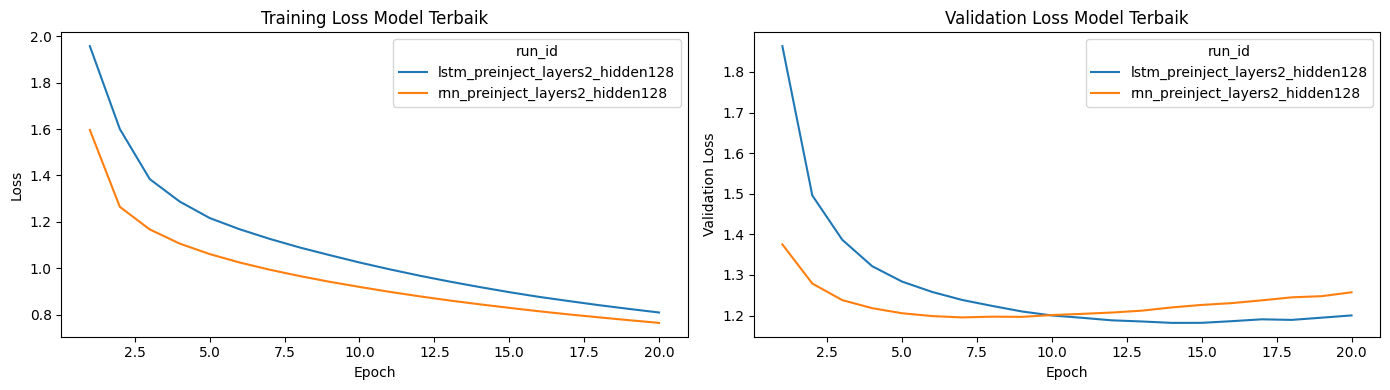

In [5]:
if not history_df.empty:
    best_run_ids = []
    if not best_rnn_df.empty:
        best_run_ids.append(best_rnn_df.iloc[0]['run_id'])
    if not best_lstm_df.empty:
        best_run_ids.append(best_lstm_df.iloc[0]['run_id'])
    selected_history = history_df[history_df['run_id'].isin(best_run_ids)].copy()
    if not selected_history.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.lineplot(data=selected_history, x='epoch', y='loss', hue='run_id', ax=axes[0])
        axes[0].set_title('Training Loss Model Terbaik')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        sns.lineplot(data=selected_history, x='epoch', y='val_loss', hue='run_id', ax=axes[1])
        axes[1].set_title('Validation Loss Model Terbaik')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Validation Loss')
        plt.tight_layout()
        plt.show()
else:
    print('training_history_long.csv belum tersedia')

Berdasarkan hasil eksperimen, konfigurasi yang paling stabil muncul pada model dengan **2 layer** dan **hidden size 128**. Pola ini terlihat pada dua decoder sekaligus. LSTM terbaik maupun RNN terbaik sama-sama berada pada kombinasi tersebut. Saat hidden size dinaikkan ke 512, skor tidak naik secara konsisten. Waktu eksekusi justru cenderung bertambah. Pada RNN, konfigurasi 512 beberapa kali turun cukup jauh dari pasangan 128 miliknya.

Pengaruh jumlah layer juga tidak sepenuhnya linear. Model 1 layer masih mampu menghasilkan caption yang masuk akal, tetapi performanya belum sekuat konfigurasi 2 layer. Saat layer dinaikkan menjadi 3, kualitas tidak otomatis membaik. Pada beberapa run, BLEU-4 justru turun. Ini memberi kesan bahwa penambahan kompleksitas belum diimbangi oleh manfaat yang cukup besar pada data dan setup yang dipakai di eksperimen ini.

Dari sisi loss, dua model terbaik layak dijadikan fokus pembahasan karena performa test-nya paling baik. Grafik training loss dan validation loss membantu melihat apakah model belajar secara stabil atau mulai kehilangan efisiensi saat kedalaman arsitektur ditambah. Jika dilihat bersama hasil test, kombinasi 2 layer dan hidden size 128 tampak paling seimbang untuk tugas ini.

## B. Perbandingan Keras vs Scratch

Bagian ini membandingkan implementasi Keras dengan implementasi forward propagation from scratch. Fokus utamanya ada pada skor akhir dan waktu eksekusi.

In [6]:
if not scratch_summary_df.empty:
    display(scratch_summary_df[['run_id', 'decoder_type', 'keras_bleu4', 'keras_meteor', 'keras_runtime_seconds', 'scratch_bleu4', 'scratch_meteor', 'scratch_runtime_seconds']])
else:
    print('File keras_vs_scratch_*.json belum tersedia')

,run_id,decoder_type,keras_bleu4,keras_meteor,keras_runtime_seconds,scratch_bleu4,scratch_meteor,scratch_runtime_seconds
0,lstm_preinject_layers1_hidden128,lstm,0.055652,0.367537,617.082655,0.021399,0.316401,3.655799
1,rnn_preinject_layers1_hidden128,rnn,0.057340,0.347912,493.604893,0.022270,0.296579,1.904534


Hasil perbandingan menunjukkan bahwa implementasi Keras masih unggul pada kualitas caption. Baik pada RNN maupun LSTM, BLEU-4 dan METEOR dari model Keras berada di atas implementasi scratch. Selisihnya cukup besar, terutama pada BLEU-4. Captioning bersifat autoregresif, jadi perbedaan kecil di langkah awal prediksi bisa menyebar ke token-token berikutnya dan membuat kalimat akhir melenceng cukup jauh.

Di sisi lain, implementasi scratch jauh lebih cepat saat inferensi. Forward pass NumPy yang sederhana memang punya overhead yang lebih kecil. Jadi ada trade-off yang jelas. Keras memberi caption yang lebih baik, sementara scratch memberi runtime yang jauh lebih singkat. Pada tugas ini, implementasi scratch tetap berguna karena menunjukkan bahwa pipeline forward propagation dari bobot hasil training bisa dijalankan tanpa bergantung pada layer Keras secara langsung.

## C. Perbandingan RNN vs LSTM

Ini adalah analisis utama. Tabel pertama merangkum model terbaik dari masing-masing decoder. Setelah itu, bagian kualitatif membandingkan caption dari model terbaik RNN dan LSTM terhadap ground truth.

In [7]:
best_compare_rows = []
if not best_rnn_df.empty:
    best_compare_rows.append(best_rnn_df.iloc[0][['run_id', 'decoder_type', 'layer_count', 'hidden_size', 'bleu4', 'meteor', 'runtime_seconds']].to_dict())
if not best_lstm_df.empty:
    best_compare_rows.append(best_lstm_df.iloc[0][['run_id', 'decoder_type', 'layer_count', 'hidden_size', 'bleu4', 'meteor', 'runtime_seconds']].to_dict())
if best_compare_rows:
    display(pd.DataFrame(best_compare_rows))
else:
    print('best_rnn.csv atau best_lstm.csv belum tersedia')

,run_id,decoder_type,layer_count,hidden_size,bleu4,meteor,runtime_seconds
0,rnn_preinject_layers2_hidden128,rnn,2,128,0.060451,0.359176,538.919824
1,lstm_preinject_layers2_hidden128,lstm,2,128,0.067935,0.365004,522.967955


In [8]:
config = load_captioning_config(ROOT / 'configs/captioning/base.json', check_data=True)
dataset = load_caption_dataset(config)
test_image_ids = list(dataset.test.image_ids)
references_by_image = {}
for record in dataset.test.records:
    references_by_image.setdefault(record.image_id, []).append(record.raw_caption.lower())
best_rnn_run = best_rnn_df.iloc[0]['run_id'] if not best_rnn_df.empty else None
best_lstm_run = best_lstm_df.iloc[0]['run_id'] if not best_lstm_df.empty else None
qualitative_df = pd.DataFrame()
if best_rnn_run and best_lstm_run:
    rnn_payload = json.loads((model_dir / best_rnn_run / 'predictions.test.json').read_text(encoding='utf-8'))
    lstm_payload = json.loads((model_dir / best_lstm_run / 'predictions.test.json').read_text(encoding='utf-8'))
    rows = []
    for image_id, rnn_pred, lstm_pred in zip(test_image_ids, rnn_payload['predictions'], lstm_payload['predictions']):
        refs = references_by_image[image_id]
        rnn_bleu = sentence_bleu(refs, rnn_pred)
        lstm_bleu = sentence_bleu(refs, lstm_pred)
        rows.append({'image_id': image_id, 'ground_truths': refs, 'rnn_prediction': rnn_pred, 'lstm_prediction': lstm_pred, 'rnn_bleu4': rnn_bleu, 'lstm_bleu4': lstm_bleu, 'mean_bleu4': (rnn_bleu + lstm_bleu) / 2.0})
    qualitative_df = pd.DataFrame(rows).sort_values('mean_bleu4', ascending=False).reset_index(drop=True)
if not qualitative_df.empty:
    top_examples = qualitative_df.head(4)
    mid_start = max(len(qualitative_df) // 2 - 1, 0)
    mid_examples = qualitative_df.iloc[mid_start:mid_start + 3]
    low_examples = qualitative_df.tail(3)
    selected_examples = pd.concat([top_examples, mid_examples, low_examples], ignore_index=True)
    display(selected_examples[['image_id', 'ground_truths', 'rnn_prediction', 'lstm_prediction', 'rnn_bleu4', 'lstm_bleu4']])
else:
    print('Predictions test untuk best RNN dan best LSTM belum tersedia')

,image_id,ground_truths,rnn_prediction,lstm_prediction,rnn_bleu4,lstm_bleu4
0,3624327440_bef4f33f32.jpg,[a man dressed in black is surfing on a large ...,a surfer is riding a wave,a surfer is riding a wave,1.000000,1.000000
1,317488612_70ac35493b.jpg,"[a dog is playing in the deep snow ., a dog ru...",a white dog is running through the snow,a white dog is running through the snow,1.000000,1.000000
2,3162045919_c2decbb69b.jpg,[a lone surfer on a white surfboard atop a hug...,a man in a wetsuit is surfing on a big wave,a surfer in a wetsuit is surfing,0.648412,0.930605
3,2938747424_64e64784f0.jpg,[a pale colored dog runs through a body of wat...,a dog is running through the snow,a white dog is running through the snow,0.557800,0.840896
4,3332467180_d72f9b067d.jpg,[a man in a white restaraunt shirt smokes next...,a young boy wearing a red shirt is standing on...,a young boy in a red shirt is playing on a red...,0.000000,0.000000
5,3270691950_88583c3524.jpg,"[a man dives into a lake ., a man dives into t...",a man in a wetsuit is surfing on a surfboard,a young boy is jumping off of a rock face,0.000000,0.000000
6,2100816230_ff866fb352.jpg,"[a man in yellow jumps with his skis ., a man ...",a man is snowboarding over a tree,a person is riding a bike through a forest,0.000000,0.000000
7,3502993968_4ee36afb0e.jpg,[a bike rider in green jersey races along a ro...,a man is doing a trick on a bike,a man is riding a bike on a dirt path,0.000000,0.000000
8,3692593096_fbaea67476.jpg,"[airplane emitting heavy red colored smoke ., ...",a man is sitting on a bench with a large wheel,a man in a red jacket is riding a horse,0.000000,0.000000
9,1446053356_a924b4893f.jpg,[children participate in a sport on a green fi...,a boy in a red and white uniform is running in...,two boys playing soccer,0.000000,0.000000


Model terbaik LSTM berada di atas model terbaik RNN, baik pada BLEU-4 maupun METEOR. Selisihnya memang tidak sangat besar, tetapi tetap konsisten. Pada eksperimen ini LSTM juga lebih cepat saat evaluasi test, sehingga ia unggul bukan hanya pada kualitas, tetapi juga pada runtime model terbaiknya.

Dari sisi konsep, hasil ini cukup selaras dengan karakter dasar kedua arsitektur. RNN standar lebih mudah kehilangan informasi saat urutan token makin panjang. LSTM punya cell state dan mekanisme gate yang membantu menjaga informasi penting lebih lama. Dalam tugas captioning, kemampuan ini berguna saat model harus mempertahankan konteks awal kalimat sambil terus memprediksi token berikutnya.

Bagian kualitatif di atas sebaiknya dipakai untuk membaca pola konkret. Fokusnya bukan hanya melihat caption mana yang benar atau salah, tetapi juga memperhatikan kecenderungan tiap decoder. LSTM biasanya lebih stabil dalam mempertahankan objek utama dan aktivitas, sedangkan RNN lebih mudah jatuh ke caption yang generik atau kehilangan relasi penting di dalam gambar.

## D. Pengaruh Panjang Maksimum Caption

Bagian ini melihat apakah perubahan nilai `max_caption_length` memberi dampak pada BLEU-4 dan METEOR.

,max_caption_length,run_id,decoder_type,bleu4,meteor,runtime_seconds
0,20,lstm_preinject_layers2_hidden128,lstm,0.067935,0.365004,466.485597
1,30,lstm_preinject_layers2_hidden128,lstm,0.067935,0.365004,467.723208
2,40,lstm_preinject_layers2_hidden128,lstm,0.067935,0.365004,478.872666
3,20,rnn_preinject_layers2_hidden128,rnn,0.060478,0.359195,547.800300
4,30,rnn_preinject_layers2_hidden128,rnn,0.060451,0.359176,533.684247
5,40,rnn_preinject_layers2_hidden128,rnn,0.060451,0.359176,518.155937


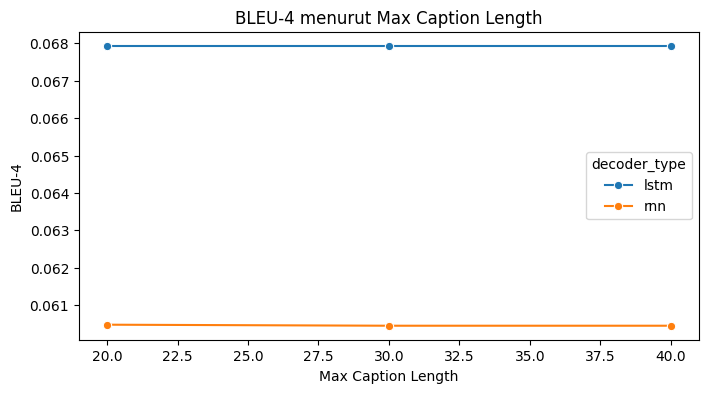

In [9]:
if not max_length_df.empty:
    display(max_length_df)
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=max_length_df, x='max_caption_length', y='bleu4', hue='decoder_type', marker='o')
    plt.title('BLEU-4 menurut Max Caption Length')
    plt.xlabel('Max Caption Length')
    plt.ylabel('BLEU-4')
    plt.show()
else:
    print('max_caption_length_comparison.csv belum tersedia')

Pada hasil yang tersedia, perubahan panjang maksimum caption tidak selalu mengubah skor. Jika nilai BLEU-4 dan METEOR tetap sama pada beberapa panjang berbeda, kemungkinan model sudah menghasilkan token `<end>` lebih awal sehingga ruang tambahan tidak benar-benar dipakai. Dalam situasi seperti itu, memperbesar batas panjang caption tidak memberi keuntungan pada kualitas, hanya menambah ruang inferensi yang pada praktiknya tidak banyak digunakan.

Kesimpulan akhir untuk bagian ini sebaiknya mengikuti isi tabel yang muncul saat notebook dijalankan. Jika kedua decoder sudah masuk ke file perbandingan, pembahasan bisa langsung dibuat untuk RNN dan LSTM sekaligus.